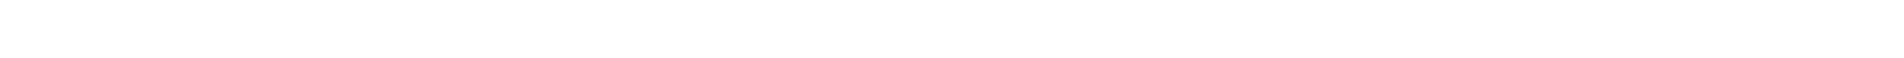

In [ ]:
import marimo as mo
import anywidget
import traitlets
from datetime import datetime, timedelta

In [ ]:
# component
class TimeInput(anywidget.AnyWidget):
    value = traitlets.Unicode("12:00").tag(sync=True)
    label = traitlets.Unicode("Saat Seçin").tag(sync=True)

    _esm = """
    function render({ model, el }) {
      const container = document.createElement("div");
      container.style.display = "inline-flex";
      container.style.alignItems = "center";
      container.style.gap = "8px";

      const label = document.createElement("label");
      label.textContent = model.get("label");
      label.style.fontSize = "14px";
      label.style.fontWeight = "500";

      const input = document.createElement("input");
      input.type = "time";
      input.value = model.get("value") || "12:00";
      input.style.padding = "4px 8px";
      input.style.borderRadius = "6px";
      input.style.border = "1px solid #ccc";
      input.style.fontFamily = "inherit";

      input.addEventListener("input", (e) => {
        model.set("value", e.target.value);
        model.save_changes();
      });

      model.on("change:value", () => {
        input.value = model.get("value");
      });

      container.appendChild(label);
      container.appendChild(input);
      el.appendChild(container);
    }
    export default { render };
    """

Dikdörtgenin alanını hesaplama

In [ ]:
def dikgortgen(kisa_kenar, uzun_kenar):
    alan = kisa_kenar * uzun_kenar
    cevre = kisa_kenar * 2 + uzun_kenar * 2
    return {"cevre": cevre, "alan": alan}

In [ ]:
print(dikgortgen(5, 7))

{'cevre': 24, 'alan': 35}


125 dakikayı saat ve dakika cinsinden ifade eden bir kod yazın (ör. "2 saat 5 dakika"). İpucu: // ve %
operatörlerini birlikte kullanın.

In [ ]:
def dakika_to_saat(dakika):
    saat = dakika // 60
    kalan = dakika % 60
    return {"saat": saat, "dakika": kalan}

In [ ]:
print(dakika_to_saat(125))

{'saat': 2, 'dakika': 5}


Aşağıdaki ifadenin sonucunu önce elle hesaplayın, sonra kodla doğrulayın: 3 + 4 * 2 ** 2 - 6 // 3

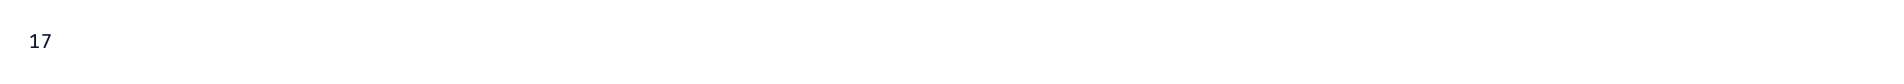

In [ ]:
3 + 4 * 2**2 - 6 // 3

Kullanıcıdan input() ile iki sayı alıp (dikkat: input() me n döndürür, dönüştürmeniz gerekir) toplamını, farkını
ve çarpımını ekrana yazdıran bir program yazın.

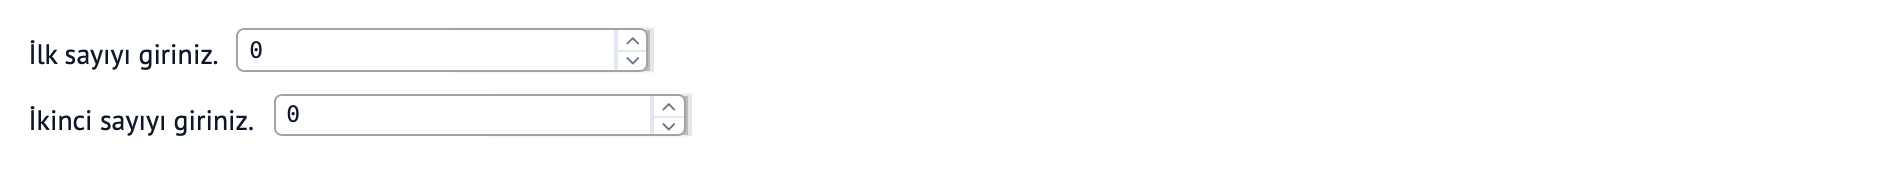

In [ ]:
def hesap(ilk, iki):
    toplam = ilk + iki
    fark = ilk - iki
    carpim = ilk * iki
    return {"toplam": toplam, "fark": fark, "carpim": carpim}

birinci_sayi = mo.ui.number(value=0, label="İlk sayıyı giriniz.")
ikinci_sayi = mo.ui.number(value=0, label="İkinci sayıyı giriniz.")
mo.vstack([birinci_sayi, ikinci_sayi])

In [ ]:
sonuc = hesap(birinci_sayi.value, ikinci_sayi.value)
mo.md(f"""
- **Toplam:** {sonuc["toplam"]}
- **Fark:** {sonuc["fark"]}
- **Çarpım:** {sonuc["carpim"]}
""")

<span class="markdown prose dark:prose-invert contents"><ul>
<li><strong>Toplam:</strong> 0</li>
<li><strong>Fark:</strong> 0</li>
<li><strong>Çarpım:</strong> 0</li>
</ul></span>

Bir sayının 3'e de 5'e de tam bölünüp bölünmediğini mod operatörünü kullanarak kontrol eden bir kod yazın
(FizzBuzz probleminin ilk adımı).

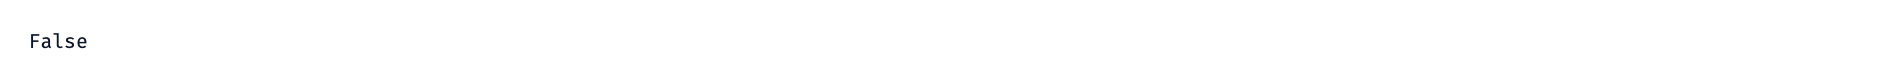

In [ ]:
def fizzbuzz(sayi):
    if sayi % 3 == 0 and sayi % 5 == 0:
        return True
    else:
        return False

fizzbuzz(10)

Basit faiz formülünü (Anapara × Faiz Oranı × Yıl) kullanarak, kullanıcıdan alınan anapara, yıllık faiz oranı (%)
ve yıl bilgisiyle toplam faiz tutarını hesaplayan bir program yazın.

In [ ]:
def faiz_hesap(anapara, faiz, yil):
    return anapara * faiz * yil

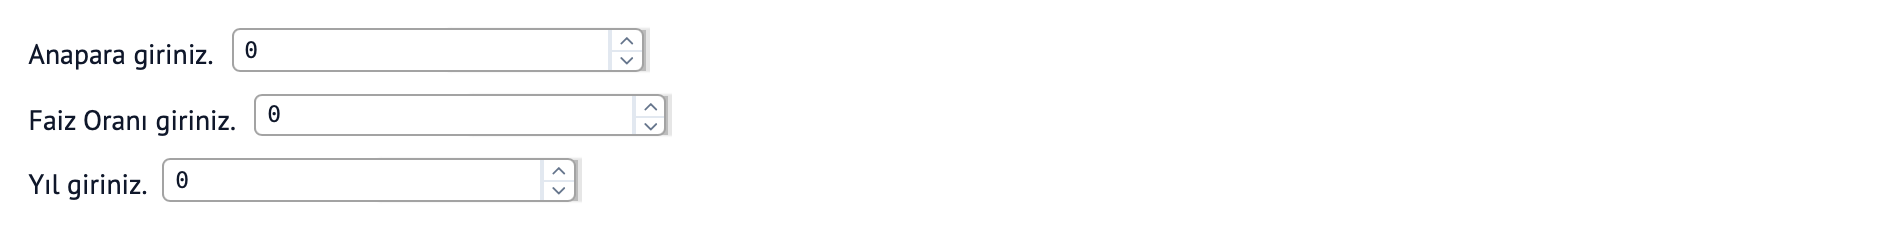

In [ ]:
anapara = mo.ui.number(value=0, label="Anapara giriniz.")
faiz = mo.ui.number(value=0, stop=100, label="Faiz Oranı giriniz.")
yil = mo.ui.number(value=0, label="Yıl giriniz.")
mo.vstack([anapara, faiz, yil])

In [ ]:
faizz = faiz_hesap(anapara.value, faiz.value, yil.value)
mo.md(f"""
- **Faiz tutarı:** {faizz}
""")

<span class="markdown prose dark:prose-invert contents"><ul>
<li><strong>Faiz tutarı:</strong> 0</li>
</ul></span>

Etkinlik süresi hesaplayıcı

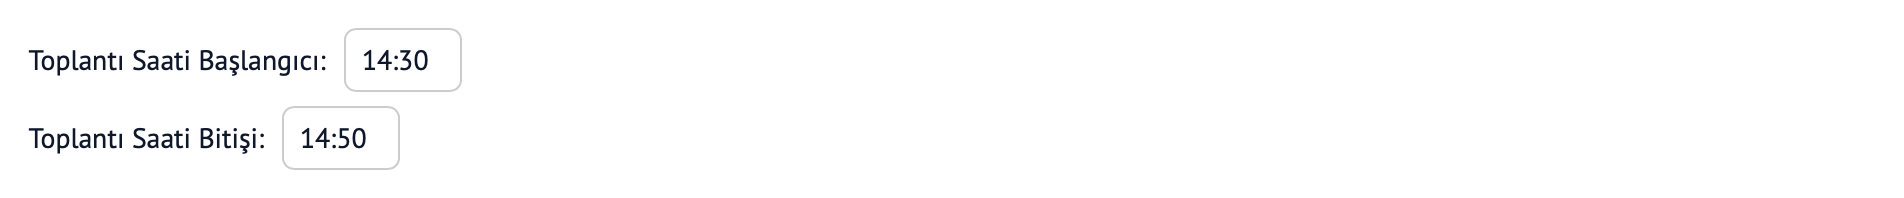

In [ ]:
baslangic = mo.ui.anywidget(
    TimeInput(value="14:30", label="Toplantı Saati Başlangıcı:")
)
bitis = mo.ui.anywidget(
    TimeInput(value="14:50", label="Toplantı Saati Bitişi:")
)
mo.vstack([baslangic, bitis])

In [ ]:
def zaman_araligi(val1, val2):
    def _get_val(v):
        if hasattr(v, "value"):
            v = v.value
        if isinstance(v, dict):
            return str(v.get("value", "12:00"))
        return str(v)

    s1 = _get_val(val1)
    s2 = _get_val(val2)
    fmt = "%H:%M"
    dt1 = datetime.strptime(s1.strip(), fmt)
    dt2 = datetime.strptime(s2.strip(), fmt)

    fark = dt2 - dt1
    if fark < timedelta(0):
        fark += timedelta(days=1)

    toplam_dakika = int(fark.total_seconds() // 60)
    saat = toplam_dakika // 60
    dakika = toplam_dakika % 60

    return saat, dakika, toplam_dakika

In [ ]:
saat, dakika, toplam_dk = zaman_araligi(baslangic.value, bitis.value)

mo.md(f"""
- **Başlangıç:** `{baslangic}`
- **Bitiş:** `{bitis}`
- **Fark:** **{saat} saat {dakika} dakika** *(Toplam {toplam_dk} dk)*
""")

<span class="markdown prose dark:prose-invert contents"><ul>
<li><strong>Başlangıç:</strong> <code>&lt;marimo-ui-element object-id='DnEU-0' random-id='7ace4777-fa91-7cd9-9022-6db591fc354f'&gt;&lt;marimo-anywidget data-initial-value='{&amp;quot;model_id&amp;quot;:&amp;quot;d9d4ea336a9c4ef493676ab7fb65e649&amp;quot;}' data-label='null' data-model-id='&amp;quot;d9d4ea336a9c4ef493676ab7fb65e649&amp;quot;'&gt;&lt;/marimo-anywidget&gt;&lt;/marimo-ui-element&gt;</code></li>
<li><strong>Bitiş:</strong> <code>&lt;marimo-ui-element object-id='DnEU-1' random-id='b2f389c8-f21a-2de6-53fe-368a964da3d7'&gt;&lt;marimo-anywidget data-initial-value='{&amp;quot;model_id&amp;quot;:&amp;quot;ce64eb6dc8b841818a1b0ede021b5c17&amp;quot;}' data-label='null' data-model-id='&amp;quot;ce64eb6dc8b841818a1b0ede021b5c17&amp;quot;'&gt;&lt;/marimo-anywidget&gt;&lt;/marimo-ui-element&gt;</code></li>
<li><strong>Fark:</strong> <strong>0 saat 20 dakika</strong> <em>(Toplam 20 dk)</em></li>
</ul></span>